In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [6]:


file_path = "../data/MEDHA_Synthetic_1000x30-1.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Longitudinal_Data"
)

print("Shape:", df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/MEDHA_Synthetic_1000x30-1.xlsx'

In [7]:
print("Number of columns:", len(df.columns))

for i, col in enumerate(df.columns):
    print(i, col)

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 83 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Victim_ID                        30000 non-null  str           
 1   Case_ID                          30000 non-null  str           
 2   Timepoint                        30000 non-null  int64         
 3   Date_Time                        30000 non-null  datetime64[us]
 4   Case_Type                        30000 non-null  str           
 5   Case_Stage                       30000 non-null  str           
 6   Checkin_Available                30000 non-null  int64         
 7   Mood                             26955 non-null  float64       
 8   Stress                           26955 non-null  float64       
 9   Sleep                            26955 non-null  float64       
 10  Functioning                      26955 non-null  float64       
 11  

In [ ]:
pd.set_option("display.max_rows", 100)

print(df.dtypes)

Victim_ID                                     str
Case_ID                                       str
Timepoint                                   int64
Date_Time                          datetime64[us]
Case_Type                                     str
Case_Stage                                    str
Checkin_Available                           int64
Mood                                      float64
Stress                                    float64
Sleep                                     float64
Functioning                               float64
Safety                                    float64
Social_Support_Checkin                    float64
Self_Reported_Wellbeing                   float64
Response_Delay_Hours                      float64
Missed_Checkin                              int64
Interaction_Frequency_7d                    int64
Session_Duration_Minutes                  float64
Engagement_Score                          float64
Engagement_Deviation                      float64


In [ ]:
print("Future_Escalation_Label" in df.columns)
print(df["Future_Escalation_Label"].value_counts(dropna=False))
print(
    df["Future_Escalation_Label"]
    .value_counts(normalize=True, dropna=False)
)

True
Future_Escalation_Label
0.0    21389
NaN     7000
1.0     1611
Name: count, dtype: int64
Future_Escalation_Label
0.0    0.712967
NaN    0.233333
1.0    0.053700
Name: proportion, dtype: float64


In [ ]:
model_df = df[
    df["Future_Escalation_Label"].notna()
].copy()

print("Original:", len(df))
print("Usable for ML:", len(model_df))

Original: 30000
Usable for ML: 23000


In [ ]:
print(
    model_df.groupby("Victim_ID")
    .size()
    .describe()
)

count    1000.0
mean       23.0
std         0.0
min        23.0
25%        23.0
50%        23.0
75%        23.0
max        23.0
dtype: float64


In [ ]:
print(
    model_df.groupby("Victim_ID")["Timepoint"]
    .agg(["min", "max", "count"])
    .head(10)
)

           min  max  count
Victim_ID                 
V0001        1   23     23
V0002        1   23     23
V0003        1   23     23
V0004        1   23     23
V0005        1   23     23
V0006        1   23     23
V0007        1   23     23
V0008        1   23     23
V0009        1   23     23
V0010        1   23     23


In [ ]:
victims = model_df["Victim_ID"].unique().to_numpy()

train_victims, temp_victims = train_test_split(
    victims,
    test_size=0.30,
    random_state=42
)

val_victims, test_victims = train_test_split(
    temp_victims,
    test_size=0.50,
    random_state=42
)

print("Train victims:", len(train_victims))
print("Validation victims:", len(val_victims))
print("Test victims:", len(test_victims))

Train victims: 700
Validation victims: 150
Test victims: 150


In [ ]:
train_df = model_df[
    model_df["Victim_ID"].isin(train_victims)
].copy()

val_df = model_df[
    model_df["Victim_ID"].isin(val_victims)
].copy()

test_df = model_df[
    model_df["Victim_ID"].isin(test_victims)
].copy()

In [ ]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (16100, 83)
Validation: (3450, 83)
Test: (3450, 83)


In [ ]:
train_ids = set(train_df["Victim_ID"])
val_ids = set(val_df["Victim_ID"])
test_ids = set(test_df["Victim_ID"])

print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [ ]:
structured_features = [
    # Current check-in / wellbeing
    "Mood",
    "Stress",
    "Sleep",
    "Functioning",
    "Safety",
    "Social_Support_Checkin",
    "Self_Reported_Wellbeing",

    # Behaviour / engagement
    "Response_Delay_Hours",
    "Missed_Checkin",
    "Interaction_Frequency_7d",
    "Session_Duration_Minutes",
    "Engagement_Score",
    "Engagement_Deviation",
    "Response_Delay_Deviation",

    # Case / contextual events
    "Threat_Event",
    "Upcoming_Hearing",
    "Hearing_Completed",
    "Investigation_Delay",
    "Compensation_Delay",
    "Relocation_Stress",
    "Rehabilitation_Issue",
    "Protection_Event",

    # Protective factors
    "Family_Support",
    "Social_Support",
    "Therapist_Engagement",
    "Access_To_Services",
    "Stable_Housing",
    "Other_Protective_Factors",

    # Episode / professional context
    "Recent_Episode",
    "Episode_Severity",
    "Family_Reported_Episode",

    # Structured distress
    "DDS",

    # Personal baseline
    "Baseline_DDS",
    "Baseline_Response_Delay",
    "Baseline_Engagement",

    # Longitudinal change
    "Previous_DDS",
    "Delta_DDS",
    "DDS_Deviation_From_Baseline",

    # Current case metadata
    "Case_Type",
    "Case_Stage"
]

In [ ]:
missing_features = [
    col for col in structured_features
    if col not in model_df.columns
]

print("Missing features:", missing_features)
print("Number of selected features:", len(structured_features))
print(model_df[structured_features].dtypes)

Missing features: []
Number of selected features: 40
Mood                           float64
Stress                         float64
Sleep                          float64
Functioning                    float64
Safety                         float64
Social_Support_Checkin         float64
Self_Reported_Wellbeing        float64
Response_Delay_Hours           float64
Missed_Checkin                   int64
Interaction_Frequency_7d         int64
Session_Duration_Minutes       float64
Engagement_Score               float64
Engagement_Deviation           float64
Response_Delay_Deviation       float64
Threat_Event                     int64
Upcoming_Hearing                 int64
Hearing_Completed                int64
Investigation_Delay              int64
Compensation_Delay               int64
Relocation_Stress                int64
Rehabilitation_Issue             int64
Protection_Event                 int64
Family_Support                 float64
Social_Support                 float64
Therapist_E

In [ ]:
print(
    model_df[structured_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Episode_Severity               22846
Mood                            2374
Sleep                           2374
Stress                          2374
Safety                          2374
Social_Support_Checkin          2374
Self_Reported_Wellbeing         2374
Functioning                     2374
Delta_DDS                       1000
Previous_DDS                    1000
Response_Delay_Hours               0
Missed_Checkin                     0
Engagement_Deviation               0
Interaction_Frequency_7d           0
Session_Duration_Minutes           0
Engagement_Score                   0
Hearing_Completed                  0
Investigation_Delay                0
Compensation_Delay                 0
Relocation_Stress                  0
Rehabilitation_Issue               0
Response_Delay_Deviation           0
Threat_Event                       0
Upcoming_Hearing                   0
Social_Support                     0
Family_Support                     0
Protection_Event                   0
T

In [ ]:
checkin_cols = [
    "Mood",
    "Stress",
    "Sleep",
    "Functioning",
    "Safety",
    "Social_Support_Checkin",
    "Self_Reported_Wellbeing"
]

print(
    model_df[checkin_cols].isna().sum(axis=1).value_counts()
)
print(
    model_df.loc[
        model_df[checkin_cols].isna().any(axis=1),
        ["Victim_ID", "Timepoint"] + checkin_cols
    ].head(20)
)

0    20626
7     2374
Name: count, dtype: int64
    Victim_ID  Timepoint  Mood  Stress  Sleep  Functioning  Safety  \
7       V0001          8   NaN     NaN    NaN          NaN     NaN   
11      V0001         12   NaN     NaN    NaN          NaN     NaN   
12      V0001         13   NaN     NaN    NaN          NaN     NaN   
30      V0002          1   NaN     NaN    NaN          NaN     NaN   
76      V0003         17   NaN     NaN    NaN          NaN     NaN   
90      V0004          1   NaN     NaN    NaN          NaN     NaN   
93      V0004          4   NaN     NaN    NaN          NaN     NaN   
97      V0004          8   NaN     NaN    NaN          NaN     NaN   
109     V0004         20   NaN     NaN    NaN          NaN     NaN   
139     V0005         20   NaN     NaN    NaN          NaN     NaN   
152     V0006          3   NaN     NaN    NaN          NaN     NaN   
189     V0007         10   NaN     NaN    NaN          NaN     NaN   
210     V0008          1   NaN     NaN    

In [ ]:
print(
    model_df[model_df["Previous_DDS"].isna()]
    .groupby("Victim_ID")
    .size()
    .describe()
)
print(
    model_df.loc[
        model_df["Previous_DDS"].isna(),
        ["Victim_ID", "Timepoint", "DDS", "Previous_DDS", "Delta_DDS"]
    ].head(20)
)

count    1000.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64
    Victim_ID  Timepoint    DDS  Previous_DDS  Delta_DDS
0       V0001          1  34.63           NaN        NaN
30      V0002          1  37.53           NaN        NaN
60      V0003          1  48.05           NaN        NaN
90      V0004          1  28.69           NaN        NaN
120     V0005          1  36.43           NaN        NaN
150     V0006          1  35.33           NaN        NaN
180     V0007          1  20.54           NaN        NaN
210     V0008          1  22.81           NaN        NaN
240     V0009          1  35.91           NaN        NaN
270     V0010          1   6.72           NaN        NaN
300     V0011          1  20.04           NaN        NaN
330     V0012          1  21.68           NaN        NaN
360     V0013          1  26.82           NaN        NaN
390     V0014          1   0.00           NaN        NaN
42

In [ ]:
print(
    pd.crosstab(
        model_df["Recent_Episode"],
        model_df["Episode_Severity"].isna(),
        margins=True
    )
)

Episode_Severity  False   True    All
Recent_Episode                       
0                     0  22846  22846
1                   154      0    154
All                 154  22846  23000


In [ ]:
print(model_df["Episode_Severity"].value_counts(dropna=False))

Episode_Severity
NaN         22846
Low            69
Moderate       63
High           22
Name: count, dtype: int64


In [ ]:
print(model_df["Case_Type"].value_counts(dropna=False))
print()
print(model_df["Case_Stage"].value_counts(dropna=False))
print(model_df[["Case_Type", "Case_Stage"]].dtypes)

Case_Type
sexual_violence                4117
witness_intimidation           4071
murder_grievous_hurt           3956
caste_based_violence           3887
arson_displacement             3680
compensation_rehabilitation    3289
Name: count, dtype: int64

Case_Stage
Investigation          7124
Compensation           6492
Trial_Preparation      5982
Investigation_Delay    1138
Complaint              1000
Post_Hearing            634
Hearing                 630
Name: count, dtype: int64
Case_Type     str
Case_Stage    str
dtype: object


In [ ]:
X_train = train_df[structured_features].copy()
y_train = train_df["Future_Escalation_Label"].astype(int)

X_val = val_df[structured_features].copy()
y_val = val_df["Future_Escalation_Label"].astype(int)

X_test = test_df[structured_features].copy()
y_test = test_df["Future_Escalation_Label"].astype(int)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (16100, 40)
X_val: (3450, 40)
X_test: (3450, 40)
y_train: (16100,)
y_val: (3450,)
y_test: (3450,)


In [ ]:
categorical_features = [
    "Episode_Severity",
    "Case_Type",
    "Case_Stage"
]

numeric_features = [
    col for col in structured_features
    if col not in categorical_features
]

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 37
Categorical: 3


In [ ]:
episode_mapping = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

for data in [X_train, X_val, X_test]:
    data["Episode_Severity"] = (
        data["Episode_Severity"]
        .map(episode_mapping)
    )

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder.fit(
    X_train[["Case_Type", "Case_Stage"]]
)

train_cat = encoder.transform(
    X_train[["Case_Type", "Case_Stage"]]
)

val_cat = encoder.transform(
    X_val[["Case_Type", "Case_Stage"]]
)

test_cat = encoder.transform(
    X_test[["Case_Type", "Case_Stage"]]
)

In [ ]:
import pandas as pd

train_cat_df = pd.DataFrame(
    train_cat,
    columns=encoder.get_feature_names_out(
        ["Case_Type", "Case_Stage"]
    ),
    index=X_train.index
)

val_cat_df = pd.DataFrame(
    val_cat,
    columns=encoder.get_feature_names_out(
        ["Case_Type", "Case_Stage"]
    ),
    index=X_val.index
)

test_cat_df = pd.DataFrame(
    test_cat,
    columns=encoder.get_feature_names_out(
        ["Case_Type", "Case_Stage"]
    ),
    index=X_test.index
)

In [ ]:
X_train_processed = pd.concat(
    [
        X_train[numeric_features + ["Episode_Severity"]],
        train_cat_df
    ],
    axis=1
)

X_val_processed = pd.concat(
    [
        X_val[numeric_features + ["Episode_Severity"]],
        val_cat_df
    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test[numeric_features + ["Episode_Severity"]],
        test_cat_df
    ],
    axis=1
)

In [ ]:
print("Processed train:", X_train_processed.shape)
print("Processed val:", X_val_processed.shape)
print("Processed test:", X_test_processed.shape)

Processed train: (16100, 51)
Processed val: (3450, 51)
Processed test: (3450, 51)


In [ ]:
print(
    X_train_processed.isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Episode_Severity            15986
Stress                       1641
Mood                         1641
Functioning                  1641
Safety                       1641
Social_Support_Checkin       1641
Self_Reported_Wellbeing      1641
Sleep                        1641
Previous_DDS                  700
Delta_DDS                     700
Response_Delay_Hours            0
Engagement_Score                0
Engagement_Deviation            0
Response_Delay_Deviation        0
Threat_Event                    0
dtype: int64


In [ ]:
print("TRAIN")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nVALIDATION")
print(y_val.value_counts())
print(y_val.value_counts(normalize=True))

print("\nTEST")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

TRAIN
Future_Escalation_Label
0    14957
1     1143
Name: count, dtype: int64
Future_Escalation_Label
0    0.929006
1    0.070994
Name: proportion, dtype: float64

VALIDATION
Future_Escalation_Label
0    3205
1     245
Name: count, dtype: int64
Future_Escalation_Label
0    0.928986
1    0.071014
Name: proportion, dtype: float64

TEST
Future_Escalation_Label
0    3227
1     223
Name: count, dtype: int64
Future_Escalation_Label
0    0.935362
1    0.064638
Name: proportion, dtype: float64


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
val_prob = model.predict_proba(
    X_val_processed
)[:, 1]

print(val_prob[:20])

[0.00979533 0.00742007 0.00692606 0.00831546 0.01079613 0.00309349
 0.01246112 0.01109295 0.00684939 0.02246292 0.04576121 0.08343611
 0.03399314 0.13632633 0.4207092  0.5257005  0.4920963  0.5362292
 0.2988444  0.22688302]


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

val_pred = (val_prob >= 0.5).astype(int)

print(
    classification_report(
        y_val,
        val_pred,
        digits=4
    )
)

print("ROC-AUC:",
      roc_auc_score(y_val, val_prob))

print("PR-AUC:",
      average_precision_score(y_val, val_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))

              precision    recall  f1-score   support

           0     0.9323    0.9922    0.9613      3205
           1     0.3590    0.0571    0.0986       245

    accuracy                         0.9258      3450
   macro avg     0.6456    0.5247    0.5299      3450
weighted avg     0.8916    0.9258    0.9000      3450

ROC-AUC: 0.8298092903307969
PR-AUC: 0.2712647772139867

Confusion Matrix:
[[3180   25]
 [ 231   14]]


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:

    pred = (val_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.to_string(index=False))

 threshold  precision   recall       f1
      0.05   0.178020 0.800000 0.291233
      0.10   0.238671 0.644898 0.348401
      0.15   0.281377 0.567347 0.376184
      0.20   0.302632 0.469388 0.368000
      0.25   0.329897 0.391837 0.358209
      0.30   0.334951 0.281633 0.305987
      0.35   0.346667 0.212245 0.263291
      0.40   0.354545 0.159184 0.219718
      0.45   0.347222 0.102041 0.157729
      0.50   0.358974 0.057143 0.098592
      0.55   0.421053 0.032653 0.060606
      0.60   0.333333 0.012245 0.023622
      0.65   0.200000 0.004082 0.008000
      0.70   0.000000 0.000000 0.000000
      0.75   0.000000 0.000000 0.000000
      0.80   0.000000 0.000000 0.000000
      0.85   0.000000 0.000000 0.000000
      0.90   0.000000 0.000000 0.000000
      0.95   0.000000 0.000000 0.000000


In [ ]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print(best_row)

threshold    0.150000
precision    0.281377
recall       0.567347
f1           0.376184
Name: 2, dtype: float64


In [ ]:
importance = pd.DataFrame({
    "feature": X_train_processed.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance.head(20).to_string(index=False))

                       feature  importance
                           DDS    0.126826
                  Previous_DDS    0.078434
   DDS_Deviation_From_Baseline    0.053017
              Engagement_Score    0.040766
                  Baseline_DDS    0.020879
      Case_Stage_Investigation    0.020674
                          Mood    0.018772
             Hearing_Completed    0.018591
                  Threat_Event    0.018087
      Response_Delay_Deviation    0.018003
       Self_Reported_Wellbeing    0.017806
Case_Type_caste_based_violence    0.017792
Case_Stage_Investigation_Delay    0.017010
  Case_Stage_Trial_Preparation    0.016785
      Session_Duration_Minutes    0.016687
          Therapist_Engagement    0.016478
           Baseline_Engagement    0.016375
       Case_Stage_Compensation    0.016326
           Investigation_Delay    0.016321
       Baseline_Response_Delay    0.016281


In [ ]:
from xgboost import XGBClassifier

weighted_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14957 / 1143,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

weighted_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
weighted_val_prob = weighted_model.predict_proba(
    X_val_processed
)[:, 1]

In [ ]:
weighted_val_pred = (
    weighted_val_prob >= 0.5
).astype(int)

print(
    classification_report(
        y_val,
        weighted_val_pred,
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, weighted_val_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, weighted_val_prob)
)

print(
    "Confusion Matrix:"
)

print(
    confusion_matrix(
        y_val,
        weighted_val_pred
    )
)

              precision    recall  f1-score   support

           0     0.9706    0.8234    0.8910      3205
           1     0.2257    0.6735    0.3381       245

    accuracy                         0.8128      3450
   macro avg     0.5981    0.7484    0.6145      3450
weighted avg     0.9177    0.8128    0.8517      3450

ROC-AUC: 0.8284389824572576
PR-AUC: 0.2687331920251054
Confusion Matrix:
[[2639  566]
 [  80  165]]


In [ ]:
baseline_roc = roc_auc_score(y_val, val_prob)
baseline_pr = average_precision_score(y_val, val_prob)

weighted_roc = roc_auc_score(y_val, weighted_val_prob)
weighted_pr = average_precision_score(y_val, weighted_val_prob)

print("Baseline")
print("ROC-AUC:", baseline_roc)
print("PR-AUC :", baseline_pr)

print("\nWeighted")
print("ROC-AUC:", weighted_roc)
print("PR-AUC :", weighted_pr)

Baseline
ROC-AUC: 0.8298092903307969
PR-AUC : 0.2712647772139867

Weighted
ROC-AUC: 0.8284389824572576
PR-AUC : 0.2687331920251054


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

configs = [
    {
        "name": "baseline",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "deeper",
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "shallower",
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "more_trees",
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "regularized",
        "n_estimators": 250,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "strong_sampling",
        "n_estimators": 250,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.7,
        "colsample_bytree": 0.7
    }
]

In [ ]:
results = []

for config in configs:

    name = config.pop("name")

    model_test = XGBClassifier(
        **config,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    model_test.fit(
        X_train_processed,
        y_train
    )

    prob = model_test.predict_proba(
        X_val_processed
    )[:, 1]

    results.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_val, prob),
        "PR_AUC": average_precision_score(y_val, prob)
    })

results_df = pd.DataFrame(results)

print(
    results_df.sort_values(
        "PR_AUC",
        ascending=False
    ).to_string(index=False)
)

          model  ROC_AUC   PR_AUC
     more_trees 0.831609 0.279454
      shallower 0.834156 0.277817
    regularized 0.830368 0.274986
strong_sampling 0.831096 0.273698
       baseline 0.829809 0.271265
         deeper 0.830757 0.265111


In [ ]:
final_candidate = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [ ]:
final_candidate.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
final_val_prob = final_candidate.predict_proba(
    X_val_processed
)[:, 1]

In [ ]:
print(
    "ROC-AUC:",
    roc_auc_score(y_val, final_val_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, final_val_prob)
)

ROC-AUC: 0.8316087745550639
PR-AUC: 0.2794538877159325


In [ ]:
thresholds = np.arange(0.05, 0.61, 0.01)

threshold_results = []

for threshold in thresholds:

    pred = (
        final_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

print(
    threshold_results
    .sort_values("f1", ascending=False)
    .head(10)
    .to_string(index=False)
)

 threshold  precision   recall       f1
      0.16   0.298673 0.551020 0.387374
      0.17   0.303241 0.534694 0.387001
      0.14   0.284000 0.579592 0.381208
      0.15   0.287815 0.559184 0.380028
      0.18   0.300481 0.510204 0.378215
      0.20   0.311828 0.473469 0.376013
      0.13   0.273743 0.600000 0.375959
      0.21   0.312676 0.453061 0.370000
      0.19   0.301546 0.477551 0.369668
      0.12   0.262238 0.612245 0.367197


In [ ]:
import shap

c:\Users\jnark\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
explainer = shap.TreeExplainer(final_candidate)

In [ ]:
shap_values = explainer.shap_values(
    X_val_processed
)

In [ ]:
shap_importance = pd.DataFrame({
    "feature": X_val_processed.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print(
    shap_importance.head(20).to_string(index=False)
)

                     feature  mean_abs_shap
                         DDS       0.618421
                Previous_DDS       0.439669
 DDS_Deviation_From_Baseline       0.300700
            Engagement_Score       0.236957
Case_Stage_Trial_Preparation       0.112794
        Engagement_Deviation       0.087578
    Other_Protective_Factors       0.086908
                Baseline_DDS       0.079673
                        Mood       0.067072
        Response_Delay_Hours       0.064211
    Session_Duration_Minutes       0.059740
              Family_Support       0.059154
         Baseline_Engagement       0.058389
        Therapist_Engagement       0.053556
                   Delta_DDS       0.053160
          Access_To_Services       0.046493
     Baseline_Response_Delay       0.042347
              Stable_Housing       0.040037
    Response_Delay_Deviation       0.039372
                      Stress       0.038186


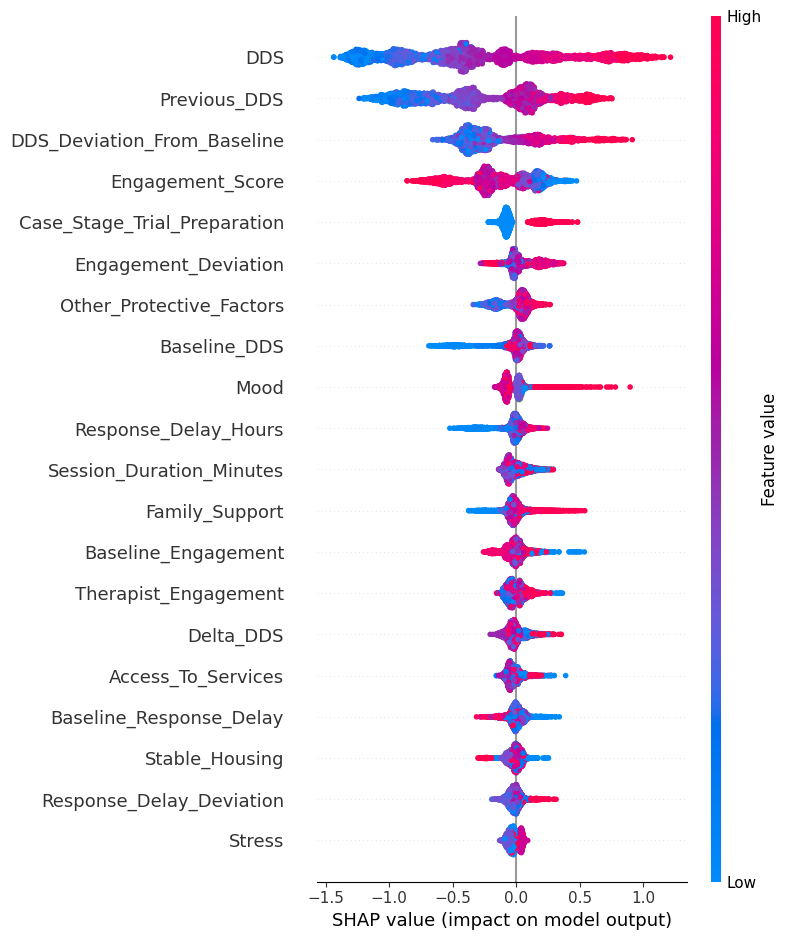

In [ ]:
shap.summary_plot(
    shap_values,
    X_val_processed,
    max_display=20
)

In [ ]:
shap_importance = pd.DataFrame({
    "feature": X_val_processed.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print(
    shap_importance.head(20).to_string(index=False)
)

                     feature  mean_abs_shap
                         DDS       0.618421
                Previous_DDS       0.439669
 DDS_Deviation_From_Baseline       0.300700
            Engagement_Score       0.236957
Case_Stage_Trial_Preparation       0.112794
        Engagement_Deviation       0.087578
    Other_Protective_Factors       0.086908
                Baseline_DDS       0.079673
                        Mood       0.067072
        Response_Delay_Hours       0.064211
    Session_Duration_Minutes       0.059740
              Family_Support       0.059154
         Baseline_Engagement       0.058389
        Therapist_Engagement       0.053556
                   Delta_DDS       0.053160
          Access_To_Services       0.046493
     Baseline_Response_Delay       0.042347
              Stable_Housing       0.040037
    Response_Delay_Deviation       0.039372
                      Stress       0.038186


In [ ]:
for col in [
    "Family_Support",
    "Social_Support",
    "Therapist_Engagement",
    "Access_To_Services",
    "Stable_Housing",
    "Other_Protective_Factors"
]:
    print("\n", col)
    print(model_df[col].value_counts(dropna=False))


 Family_Support
Family_Support
0.431    161
0.862    115
0.991    115
0.287    115
0.535    115
        ... 
0.721     23
0.652     23
0.355     23
0.868     23
0.409     23
Name: count, Length: 569, dtype: int64

 Social_Support
Social_Support
0.768    161
0.362    138
0.229    138
0.699    115
0.358    115
        ... 
0.990     23
0.745     23
0.747     23
0.218     23
0.401     23
Name: count, Length: 575, dtype: int64

 Therapist_Engagement
Therapist_Engagement
0.676    161
0.937    138
0.973    115
0.407    115
0.450    115
        ... 
0.563     23
0.433     23
0.807     23
0.332     23
0.991     23
Name: count, Length: 548, dtype: int64

 Access_To_Services
Access_To_Services
0.796    138
0.379    138
0.386    115
0.584    115
0.457    115
        ... 
0.668     23
0.438     23
0.587     23
0.256     23
0.757     23
Name: count, Length: 567, dtype: int64

 Stable_Housing
Stable_Housing
0.395    138
0.459    115
0.330    115
0.665    115
0.835    115
        ... 
0.386     23
0

In [ ]:
print(
    model_df[
        [
            "Family_Support",
            "Social_Support",
            "Therapist_Engagement",
            "Access_To_Services",
            "Stable_Housing",
            "Other_Protective_Factors",
            "Future_Escalation_Label"
        ]
    ].groupby(
        "Future_Escalation_Label"
    ).mean()
)

                         Family_Support  Social_Support  Therapist_Engagement  \
Future_Escalation_Label                                                         
0.0                            0.604497        0.593063              0.647410   
1.0                            0.594457        0.613745              0.641341   

                         Access_To_Services  Stable_Housing  \
Future_Escalation_Label                                       
0.0                                0.597783        0.653404   
1.0                                0.594966        0.648517   

                         Other_Protective_Factors  
Future_Escalation_Label                            
0.0                                      0.619000  
1.0                                      0.617129  


In [ ]:
final_test_prob = final_candidate.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
print(
    "TEST ROC-AUC:",
    roc_auc_score(y_test, final_test_prob)
)

print(
    "TEST PR-AUC:",
    average_precision_score(y_test, final_test_prob)
)

TEST ROC-AUC: 0.851038254859155
TEST PR-AUC: 0.32910604774502406


In [ ]:
final_test_pred = (
    final_test_prob >= 0.16
).astype(int)

In [ ]:
print(
    classification_report(
        y_test,
        final_test_pred,
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        final_test_pred
    )
)

              precision    recall  f1-score   support

           0     0.9644    0.9247    0.9442      3227
           1     0.3174    0.5067    0.3903       223

    accuracy                         0.8977      3450
   macro avg     0.6409    0.7157    0.6672      3450
weighted avg     0.9226    0.8977    0.9084      3450

Confusion Matrix:
[[2984  243]
 [ 110  113]]


In [ ]:
import os

os.makedirs("structured_engine", exist_ok=True)

In [ ]:
import joblib

joblib.dump(
    final_candidate,
    "structured_engine/xgboost_model.pkl"
)

joblib.dump(
    encoder,
    "structured_engine/case_encoder.pkl"
)

joblib.dump(
    episode_mapping,
    "structured_engine/episode_mapping.pkl"
)

joblib.dump(
    structured_features,
    "structured_engine/structured_features.pkl"
)

joblib.dump(
    X_train_processed.columns.tolist(),
    "structured_engine/model_columns.pkl"
)

joblib.dump(
    0.16,
    "structured_engine/threshold.pkl"
)

print("Structured Engine artifacts saved.")

Structured Engine artifacts saved.


In [ ]:
print(type(encoder))
print(encoder)

<class 'sklearn.preprocessing._encoders.OneHotEncoder'>
OneHotEncoder(handle_unknown='ignore', sparse_output=False)


In [ ]:
print(X_train_processed.columns.tolist())

['Mood', 'Stress', 'Sleep', 'Functioning', 'Safety', 'Social_Support_Checkin', 'Self_Reported_Wellbeing', 'Response_Delay_Hours', 'Missed_Checkin', 'Interaction_Frequency_7d', 'Session_Duration_Minutes', 'Engagement_Score', 'Engagement_Deviation', 'Response_Delay_Deviation', 'Threat_Event', 'Upcoming_Hearing', 'Hearing_Completed', 'Investigation_Delay', 'Compensation_Delay', 'Relocation_Stress', 'Rehabilitation_Issue', 'Protection_Event', 'Family_Support', 'Social_Support', 'Therapist_Engagement', 'Access_To_Services', 'Stable_Housing', 'Other_Protective_Factors', 'Recent_Episode', 'Family_Reported_Episode', 'DDS', 'Baseline_DDS', 'Baseline_Response_Delay', 'Baseline_Engagement', 'Previous_DDS', 'Delta_DDS', 'DDS_Deviation_From_Baseline', 'Episode_Severity', 'Case_Type_arson_displacement', 'Case_Type_caste_based_violence', 'Case_Type_compensation_rehabilitation', 'Case_Type_murder_grievous_hurt', 'Case_Type_sexual_violence', 'Case_Type_witness_intimidation', 'Case_Stage_Compensation', 

In [8]:
print(episode_mapping)

NameError: name 'episode_mapping' is not defined